In [ ]:
Name:Jangam Sahil Santosh 
Batch:B1
Roll no.13215

Assignment no.05
Problem Statement : Data Analytics II

Implement logistic regression using Python/R to perform classification on Social_Network_Ads.csv dataset.
Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("Social_Network_Ads (1).csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [4]:
df.info

<bound method DataFrame.info of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [13]:
df.describe

<bound method NDFrame.describe of      Age  EstimatedSalary  Purchased
0     19            19000          0
1     35            20000          0
2     26            43000          0
3     27            57000          0
4     19            76000          0
..   ...              ...        ...
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1

[400 rows x 3 columns]>

In [5]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[18, 30, 45, 60],
                        labels=['Young', 'Adult', 'Senior'])

print(df[['Age', 'Age_Group']].head())

   Age Age_Group
0   19     Young
1   35     Adult
2   26     Young
3   27     Young
4   19     Young


In [6]:
print(df.dtypes)

User ID               int64
Gender               object
Age                   int64
EstimatedSalary       int64
Purchased             int64
Age_Group          category
dtype: object


In [7]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased',
       'Age_Group'],
      dtype='object')

In [8]:
print(df.shape)


(400, 6)


In [9]:
print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
Age_Group          5
dtype: int64


In [10]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [13]:
df['Age'] = df['Age'].astype(int)

In [14]:
scaler = MinMaxScaler()
X = df[['Age', 'EstimatedSalary']]
X_scaled = scaler.fit_transform(X)
df_normalized = pd.DataFrame(X_scaled, columns=['Age', 'EstimatedSalary'])
print(df_normalized.head())

        Age  EstimatedSalary
0  0.023810         0.029630
1  0.404762         0.037037
2  0.190476         0.207407
3  0.214286         0.311111
4  0.023810         0.451852


In [15]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased,Age_Group
0,15624510,Male,19,19000,0,Young
1,15810944,Male,35,20000,0,Adult
2,15668575,Female,26,43000,0,Young
3,15603246,Female,27,57000,0,Young
4,15804002,Male,19,76000,0,Young
...,...,...,...,...,...,...
395,15691863,Female,46,41000,1,Senior
396,15706071,Male,51,23000,1,Senior
397,15654296,Female,50,20000,1,Senior
398,15755018,Male,36,33000,0,Adult


In [16]:
x = df.drop('Age',axis=1)

In [17]:
x = x.drop('Purchased', axis=1)

In [18]:
x

,User ID,Gender,EstimatedSalary,Age_Group
0,15624510,Male,19000,Young
1,15810944,Male,20000,Adult
2,15668575,Female,43000,Young
3,15603246,Female,57000,Young
4,15804002,Male,76000,Young
...,...,...,...,...
395,15691863,Female,41000,Senior
396,15706071,Male,23000,Senior
397,15654296,Female,20000,Senior
398,15755018,Male,33000,Adult


In [19]:
y = df['Purchased']

In [20]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
Age_Group          5
dtype: int64

In [21]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [22]:
X = df[['Age', 'EstimatedSalary']]   # input features
y = df['Purchased']                  # output (target)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [27]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[65  3]
 [ 8 24]]


In [34]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [35]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

In [36]:
error_rate = 1 - accuracy

In [37]:
precision = TP / (TP + FP)

In [38]:
recall = TP / (TP + FN)

In [39]:
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

TP: 24
TN: 65
FP: 3
FN: 8
Accuracy: 0.89
Error Rate: 0.10999999999999999
Precision: 0.8888888888888888
Recall: 0.75


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



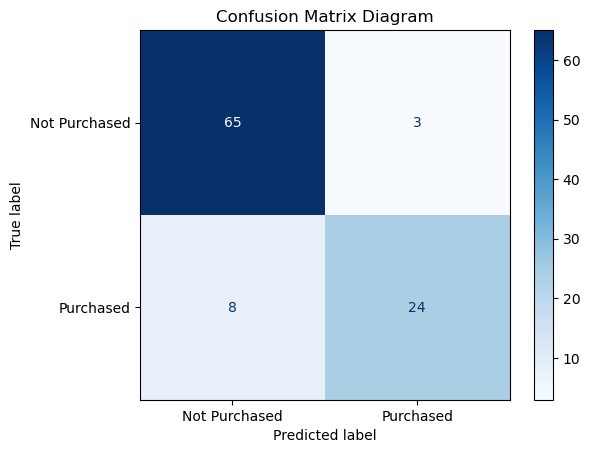

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display diagram
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Purchased", "Purchased"])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix Diagram")
plt.show()